# A Comparative Study of Statistical and Embedding-Based Models for Fake News Detection

# 1. Introduction
## 1.1 Domain-specific area: Fake News Detection in Online News Media

The growth of online news platforms and social media has significantly transformed how people access and share information. News can now spread rapidly to large audiences, but this speed and reach have also made it easier for false or misleading content, commonly referred to as fake news, to circulate widely. The spread of fake news has been shown to reduce public trust, influence political decisions, and increase social division, making it a serious challenge for modern digital societies (Allcott & Gentzkow, 2017).

Within this environment, fake news detection has emerged as an important text classification problem. The goal is to automatically determine whether a news article is credible or not based on its textual content. Relying solely on manual fact-checking is impractical, as it requires substantial human effort and cannot keep pace with the volume of content produced online. For this reason, automated approaches using Natural Language Processing (NLP) and machine learning have become increasingly important for supporting large-scale misinformation detection (Shu et al., 2017).

Early approaches to fake news detection typically relied on statistical text representation methods such as bag-of-words and term frequency–inverse document frequency (TF-IDF), combined with traditional machine learning algorithms including Naïve Bayes and Logistic Regression. These methods are relatively fast, easy to interpret, and provide strong baseline performance, making them well suited for initial misinformation screening. However, because they rely mainly on word frequency, they often struggle to capture deeper semantic meaning and contextual cues, which are important for identifying more subtle or carefully written forms of misinformation (Zhang et al., 2019).

More recent developments in NLP have introduced embedding-based language models that represent text as dense vectors encoding semantic and contextual information. Techniques such as Word2Vec enable models to learn relationships between words based on their usage patterns, improving performance by capturing semantic similarity (Mikolov et al., 2013). In addition, contextual models such as BERT consider surrounding words when interpreting meaning, enabling a more nuanced understanding of language in news articles (Devlin et al., 2019). While these models are generally more expressive, they also require greater computational resources and are often less interpretable than traditional statistical approaches.

Given these differences, fake news detection provides a particularly suitable domain for comparing traditional statistical models with modern embedding-based approaches. By evaluating both methods on the same dataset, this coursework aims to examine their relative strengths and limitations in addressing misinformation. The results contribute to a clearer understanding of how different NLP modelling strategies perform in real-world news classification tasks and highlight their potential roles in practical applications such as automated content moderation, misinformation monitoring, and decision-support systems for digital media platforms.

## 1.2 Objectives

The main objective of this coursework is to explore and compare the effectiveness of different text classification approaches for the task of fake news detection. Specifically, the project aims to evaluate a traditional statistical approach alongside a modern embedding-based language modelling approach in order to understand how different text representations influence classification performance in the context of automated misinformation detection.

The first objective is to design and implement a statistical baseline model for fake news detection using frequency-based text representations and a classical machine learning classifier. Statistical approaches have been widely adopted in early fake news detection research due to their computational efficiency, simplicity, and interpretability, making them suitable for large-scale analysis of online news content (Shu et al., 2017). This objective seeks to assess how effectively such models can distinguish between credible and non-credible news articles when relying primarily on lexical and frequency-based information, and to establish a meaningful benchmark for comparison.

The second objective is to implement an embedding-based text classification approach that captures richer semantic and contextual information from news articles. Recent advances in Natural Language Processing have shown that embedding-based models can improve text understanding by modelling word meaning in relation to surrounding context (Devlin et al., 2019). This objective aims to examine whether such representations provide measurable improvements in classification performance over traditional statistical methods, particularly in detecting more nuanced or subtly written forms of misinformation.

A further objective of this coursework is to conduct a systematic comparative evaluation of the two approaches using standard classification metrics, including accuracy, precision, recall, and F1-score. Through this evaluation, the project aims to identify the strengths, limitations, and trade-offs associated with each modelling strategy, including performance, interpretability, and computational complexity.

Overall, the objectives of this coursework extend beyond model implementation to provide insight into the practical applicability of different NLP techniques for fake news detection. By analysing and comparing statistical and embedding-based approaches, the findings aim to inform the selection of appropriate text classification methods for real-world misinformation monitoring and content moderation systems.

## 1.3 Dataset Description
This project uses the Fake and Real News dataset, which is publicly available from Kaggle and was originally published by Bisaillon (2018). The dataset is designed specifically for fake news detection tasks and contains labelled news articles suitable for supervised text classification.

The dataset is provided in two separate CSV files: Fake.csv and True.csv. The Fake.csv file contains news articles labelled as fake, while the True.csv file contains news articles labelled as real. Both files were downloaded directly from Kaggle and stored locally for analysis.

In [1]:
import pandas as pd

fake_df = pd.read_csv("Fake.csv")
true_df = pd.read_csv("True.csv")


The size of each dataset was inspected to understand the number of samples available for each class. The Fake.csv file contains 23,481 fake news articles, while the True.csv file contains 21,417 real news articles, indicating a relatively balanced dataset suitable for binary classification. Each dataset contains 4 columns, representing the article title, full text content, subject category, and publication date.

In [2]:
fake_df.shape, true_df.shape


((23481, 4), (21417, 4))

To enable supervised learning, a binary label was assigned to each dataset, where fake news articles were labelled as 0 and real news articles were labelled as 1. The two datasets were then combined into a single dataframe. After merging, the final dataset contains 44,898 news articles with five columns, where the additional column represents the class label used as the target variable for classification. 

In [3]:
fake_df["label"] = 0
true_df["label"] = 1

df = pd.concat([fake_df, true_df], ignore_index=True)
df.shape


(44898, 5)

The variable TEXT_COL is used to clearly indicate which column contains the article text that will be used for modelling. Converting this column to a string format helps ensure that all entries are handled consistently during preprocessing and avoids potential issues caused by missing or non-text values. The preview that is printed afterwards is simply used to double-check that the text and label columns were merged correctly.

In [4]:
TEXT_COL = "text"
df[TEXT_COL] = df[TEXT_COL].astype(str)

print("raw rows:", len(df))
print(df[[TEXT_COL, "label"]].head(2))

raw rows: 44898
                                                text  label
0  Donald Trump just couldn t wish all Americans ...      0
1  House Intelligence Committee Chairman Devin Nu...      0


This preview confirms that the dataset was merged correctly and that the label values correspond to the expected fake (0) and real (1) classes.

In [5]:
df.head()


,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0


Verifying data types at this stage ensures that the text columns can be processed by natural language preprocessing pipelines and that the label column can be used directly as a numerical target variable by machine learning models.

In [6]:
df.dtypes

title      object
text       object
subject    object
date       object
label       int64
dtype: object

The dataset was acquired by downloading pre-labelled CSV files from Kaggle and loading them using the Python pandas library. No additional data collection or manual annotation was required. Due to its size, clear structure, and relevance to misinformation detection, the dataset is representative of the fake news detection challenge and suitable for comparing statistical and embedding-based text classification approaches.
One limitation of the dataset is that it focuses on English-language news articles and does not capture multimodal misinformation such as images or videos, which may affect real-world deployment. Despite this limitation, the dataset remains appropriate for evaluating and comparing statistical and embedding-based text classification approaches due to its size, balance, and realistic news-style language.

## 1.4 Evaluation Methodology

To evaluate the performance of the fake news classification models, several standard classification metrics are used. These metrics provide a comprehensive assessment of how well each model distinguishes between fake and real news articles, and allow for a fair comparison between the statistical and embedding-based approaches.

Accuracy is used as an overall measure of model performance and represents the proportion of correctly classified news articles out of all predictions. While accuracy provides a useful high-level overview, it can be misleading when used in isolation, particularly if class imbalance exists. Therefore, additional metrics are required to better understand model behaviour.

Precision measures the proportion of articles predicted as fake news that are actually fake. This metric is important in the context of misinformation detection because incorrectly labelling real news as fake can undermine trust in legitimate sources. A high precision score indicates that the model is reliable when it flags content as fake.

Recall measures the proportion of actual fake news articles that are correctly identified by the model. High recall is crucial for fake news detection, as failing to identify misinformation allows it to continue spreading. This metric reflects the model’s ability to capture as many fake news instances as possible.

The F1-score is the harmonic mean of precision and recall and provides a balanced measure that considers both false positives and false negatives. It is particularly useful when comparing models, as it summarises overall classification performance in a single value while accounting for trade-offs between precision and recall.

These metrics are applied consistently to both the statistical model and the embedding-based model using the same test dataset. This ensures that any differences in performance can be attributed to the modelling approach rather than variations in the evaluation process. By comparing the metric scores across both models, it is possible to assess not only which approach performs better overall, but also how each model handles different types of classification errors.

In addition to numerical metrics, confusion matrices are used to visualise model predictions and error patterns. This allows for a clearer interpretation of misclassification behaviour, such as whether a model tends to mislabel real news as fake or vice versa. Together, these evaluation methods provide a robust framework for comparing traditional statistical and modern embedding-based text classification approaches in the context of fake news detection.

# 2. Implementation

## 2.1 Data Preprocessing  
This section describes how the raw news articles were prepared before training the models. The purpose of preprocessing is to clean and organise the text, remove low-quality or uninformative samples, and convert the articles into a numerical form that machine learning models can process. This includes cleaning the text, removing empty and duplicate entries, splitting the data into training and test sets, and representing the text using both TF-IDF and BERT-based tokenisation. Together, these steps ensure that the dataset is clean, consistent, and suitable for both statistical and embedding-based text classification.
### 2.1.1 Import Required Libraries
The required Python libraries were imported to enable data preprocessing, feature extraction, and model training. These libraries provide functionality for text cleaning, dataset splitting, vectorisation, and embedding construction, which are used in the subsequent stages of the workflow.

In [7]:
# Core utilities
import re
import numpy as np
import pandas as pd

# Scikit-learn (data prep, models, metrics)
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

# Transformers and tokenisation
from transformers import AutoTokenizer, BertForSequenceClassification

# PyTorch
import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

# Utilities
from tqdm import tqdm

# Visualisation
import matplotlib.pyplot as plt

# Reproducibility
SEED = 42
np.random.seed(SEED)



### 2.1.2 Basic Text Cleaning

The raw news article text contains various forms of noise, such as URLs, HTML tags, punctuation, and inconsistent casing, which can negatively affect text representation and model performance. To address this, a basic text-cleaning process was applied to standardise the input while preserving meaningful linguistic content.

Two separate cleaning functions were used. A stronger cleaning function was applied for the TF-IDF representation to reduce vocabulary size and sparsity, while a lighter cleaning function was applied for BERT in order to preserve punctuation and casing so that the tokenizer could make use of the original linguistic structure.

The preprocessing steps include converting text to lowercase (for TF-IDF), removing URLs and HTML tags, removing non-alphabetic characters (for TF-IDF), and normalising whitespace. Stopword removal and lemmatisation were intentionally not applied to avoid removing stylistic cues and negation terms (such as “not” and “never”) that may be important for fake news detection.

In [8]:
def clean_text_tfidf(s: str) -> str:
    if pd.isna(s):
        return ""
    s = s.lower()
    s = re.sub(r"http\S+|www\.\S+", " ", s)
    s = re.sub(r"<.*?>", " ", s)
    s = re.sub(r"\brt\b", " ", s)              # remove standalone 'rt'
    s = re.sub(r"[^a-z\s]", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

def clean_text_bert(s: str) -> str:
    """Light cleaning for BERT: remove URLs/HTML, normalise whitespace (keep punctuation/case)."""
    if pd.isna(s):
        return ""
    s = re.sub(r"http\S+|www\.\S+", " ", s)
    s = re.sub(r"<.*?>", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

df["text_tfidf"] = df[TEXT_COL].apply(clean_text_tfidf)
df["text_bert"]  = df[TEXT_COL].apply(clean_text_bert)


The cleaning functions were applied to the full dataset. Articles that became empty after cleaning were removed, very short articles were filtered out to reduce low-information noise, and duplicate articles were removed to prevent the model from being biased by repeated content.

In [9]:
df = df[df["text_tfidf"].str.len() > 0]
df = df[df["text_tfidf"].str.len() >= 20]
df = df.drop_duplicates(subset=["title", "text_tfidf"]).reset_index(drop=True)


print("rows after cleaning/filtering:", len(df))


rows after cleaning/filtering: 38302


After preprocessing, the dataset was reduced to 38,286 articles, reflecting the removal of empty, extremely short, and duplicated entries. This results in a cleaner and more consistent dataset that is better suited for training both statistical and embedding-based models.

### 2.1.3 Train–Test Split

The dataset was divided into training and test sets in order to evaluate model performance on previously unseen data. This separation ensures that performance metrics reflect the model’s ability to generalise beyond the data it was trained on, rather than simply memorising patterns from the training set.

A stratified split was used to preserve the original class distribution in both the training and test subsets. This is particularly important for classification tasks, as it prevents class imbalance from being introduced during the splitting process and ensures that both subsets remain representative of the overall dataset.

The split was performed before feature extraction to prevent information leakage from the test data into the training process. This ensures that all feature representations are learned exclusively from the training data, maintaining the validity of the evaluation.

In [10]:
X_tfidf = df["text_tfidf"].values
X_bert  = df["text_bert"].values
y       = df["label"].values

X_tfidf_train, X_tfidf_test, X_bert_train, X_bert_test, y_train, y_test = train_test_split(
    X_tfidf, X_bert, y,
    test_size=0.2,
    random_state=SEED,
    stratify=y
)

print("train size:", len(y_train))
print("test size:", len(y_test))


train size: 30641
test size: 7661


The resulting split allocates 30,628 articles to the training set and 7,658 articles to the test set. This 80–20 division provides a sufficient amount of data for training while reserving a substantial and representative portion of the dataset for reliable evaluation.

### 2.1.4 Text Representation

To enable machine learning models to process the news articles, the cleaned text must be converted into numerical form. Two different text representation strategies are used in this study. For the statistical approach, TF-IDF is applied to produce sparse frequency-based feature vectors. For the embedding-based approach, the articles are tokenised and encoded using the BERT tokenizer to generate dense, context-aware token representations along with corresponding attention masks.

These two representations reflect different assumptions about how text should be modelled. TF-IDF captures word importance based on frequency patterns, while BERT captures semantic and syntactic relationships by modelling each word in context.

#### 2.1.4.1 TF-IDF Representation for Statistical Models

TF-IDF (Term Frequency–Inverse Document Frequency) represents text by assigning a weight to each word based on how frequently it appears within a document relative to how frequently it appears across the entire dataset. Words that occur often in a specific document but are relatively rare in the full corpus receive higher weights, while very common words receive lower weights.

Before computing TF-IDF, the cleaned article text is tokenised into unigrams (single words) and bigrams (two-word phrases). TF-IDF weights are then calculated over these tokens to construct sparse document–term matrices, where each document is represented as a vector of word importance scores.

For example, in a sentence such as “fake news spreads quickly,” the word “fake” may receive a high TF-IDF weight if it is characteristic of that article but uncommon across the dataset, whereas function words such as “the” or “and” receive low weights because they appear in nearly all documents. This weighting scheme allows the model to focus on informative and discriminative terms rather than general language.

This frequency-based representation is well suited to linear classifiers, as it highlights distinctive words and short phrases that help differentiate between classes. TF-IDF therefore provides a strong, efficient, and interpretable statistical baseline for text classification tasks.

In [11]:
# Create TF-IDF vectorizer
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    stop_words=None
)

# Fit on training data and transform both train and test sets
X_train_tfidf = tfidf.fit_transform(X_tfidf_train)
X_test_tfidf  = tfidf.transform(X_tfidf_test)

print("TF-IDF train shape:", X_train_tfidf.shape)
print("TF-IDF test shape:", X_test_tfidf.shape)

TF-IDF train shape: (30641, 10000)
TF-IDF test shape: (7661, 10000)


The resulting TF-IDF matrices have a dimensionality of 10,000 features, corresponding to the most informative unigrams and bigrams selected from the training corpus. The training matrix has a shape of (30,628, 10,000), meaning that 30,628 training documents are each represented by a 10,000-dimensional feature vector, while the test matrix has a shape of (7,658, 10,000), indicating that 7,658 unseen documents are represented in the same feature space.

This shared feature representation ensures consistency between model training and evaluation. Overall, the TF-IDF representation captures both term importance and limited local context, making it well suited for linear classification models in high-dimensional text settings.

#####  TF-IDF Feature Inspection and Example Output


To better understand how the TF-IDF representation captures informative terms, the learned vocabulary and the highest-weighted terms for a single training document were inspected. This step serves as a qualitative sanity check rather than a component of the training process.

The first 20 feature names illustrate the types of tokens included in the representation, including both unigrams (e.g., “abandon”, “ability”) and bigrams (e.g., “abc news”, “about billion”), confirming that the vectoriser captures both individual words and short phrases.

The top TF-IDF terms for the first training document demonstrate how the model assigns higher weights to terms that are more distinctive for that article. For example, the term “johnson” receives the highest weight, indicating that it is highly characteristic of this particular news item. More general words such as “the” and “he” receive lower weights, reflecting their limited discriminative value across the dataset.

This qualitative inspection supports the intended behaviour of the TF-IDF representation, which emphasises informative, topic-specific terms over general language.

In [12]:
# Inspect feature names
feature_names = tfidf.get_feature_names_out()
print("Sample TF-IDF features:", feature_names[:20])

# Show top TF-IDF terms for the first training document
doc_index = 0

tfidf_vector = X_train_tfidf[doc_index].toarray().flatten()

top_indices = tfidf_vector.argsort()[-10:][::-1]  # indices of top 10 highest weights
top_terms = [(feature_names[i], tfidf_vector[i]) for i in top_indices]

print("\nTop TF-IDF terms for first training document:")
for term, score in top_terms:
    print(f"{term}: {score:.4f}")



Sample TF-IDF features: ['abadi' 'abandon' 'abandoned' 'abbas' 'abc' 'abc news' 'abdullah' 'abe'
 'abedin' 'ability' 'ability to' 'able' 'able to' 'abortion' 'abortions'
 'about' 'about an' 'about billion' 'about her' 'about him']

Top TF-IDF terms for first training document:
colombia: 0.3035
the: 0.3012
pope: 0.2423
of: 0.2194
the pope: 0.1768
francis: 0.1645
and: 0.1573
conflict: 0.1404
reconciliation: 0.1270
killed: 0.1179


#### 2.1.4.2 BERT Tokenisation for Embedding-Based Models


BERT (Bidirectional Encoder Representations from Transformers) provides a contextual, embedding-based representation of text by mapping each token to a dense numerical vector that depends on its surrounding context. Unlike TF-IDF, which represents text using frequency-based features and ignores word order, BERT processes the full token sequence using a transformer architecture, allowing it to capture both semantic meaning and syntactic structure.

Before encoding, each cleaned article is tokenised using the pre-trained bert-base-uncased tokenizer. This tokenizer applies subword tokenisation, which splits rare or unseen words into smaller, known subword units. This improves robustness to vocabulary variation and reduces the impact of out-of-vocabulary terms.

Each article is then converted into a fixed-length sequence of token identifiers (input_ids) and a corresponding attention mask. The attention mask indicates which positions correspond to actual tokens and which correspond to padding. Sequences longer than a fixed maximum length are truncated, while shorter sequences are padded, ensuring consistent input dimensions across the dataset.

These encoded sequences form the embedding-based input representation for the neural model, enabling the classifier to learn contextual and semantic patterns that cannot be captured by frequency-based methods.

In [13]:
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

def bert_encode(texts, max_length=256):
    return tokenizer(
        list(texts),
        truncation=True,
        padding=True,
        max_length=max_length
        
    )

MAX_LEN = 256
bert_train_enc = bert_encode(X_bert_train, max_length=MAX_LEN)
bert_test_enc  = bert_encode(X_bert_test,  max_length=MAX_LEN)

# These are lists, so use len() instead of .shape
print("BERT train sequences:", len(bert_train_enc["input_ids"]))
print("BERT test sequences:", len(bert_test_enc["input_ids"]))
print("example token length:", len(bert_train_enc["input_ids"][0]))


BERT train sequences: 30641
BERT test sequences: 7661
example token length: 256


The BERT tokenizer was applied to the training and test sets, resulting in 30,628 tokenised training sequences and 7,658 tokenised test sequences. Each article is represented as a fixed-length sequence of 256 tokens. Shorter sequences are padded and longer sequences are truncated, ensuring that all inputs have the same length and can be processed efficiently by the neural model.

Unlike TF-IDF, which represents text using sparse frequency-based features and does not capture word order or contextual meaning, BERT produces contextualised embeddings that depend on the surrounding words in a sentence. As a result, the same word can receive different representations depending on its context, allowing the model to capture more nuanced semantic and syntactic information.

The tokenised sequences are represented numerically using token identifiers from BERT’s vocabulary, along with corresponding attention masks that indicate which positions contain real tokens and which are padding. These representations preserve word order and contextual structure and are used directly as input to the deep learning classifier.

##### Example of BERT Tokenisation and Embedding Representation

This example illustrates how a raw news article is processed by the BERT tokenizer before being passed into the embedding-based classification model. The purpose of this step is to make the tokenisation process more transparent and to verify that the input text is being converted into a suitable numerical form.

A single training example is selected and its original text is displayed alongside the corresponding BERT tokens, token IDs, and attention mask values. This allows us to observe how BERT splits the input into subword units and prepares the input sequence for the model.

The output shows that the tokenizer breaks the text into meaningful subword tokens. For example, the word “parleying” is split into the subwords “par”, “##ley”, and “##ing”, demonstrating how BERT handles rare or complex words using subword tokenisation. Special tokens such as [CLS] are added automatically to mark the beginning of the sequence, and punctuation is preserved as separate tokens, allowing the model to retain syntactic structure.

Each token is then mapped to a numerical identifier from BERT’s vocabulary. These token IDs are what the model actually receives as input. In addition, an attention mask is generated to indicate which positions correspond to real tokens (1) and which positions are padding (0). In this example, the first 20 attention mask values are all 1, showing that these positions contain valid tokens from the original text.

Overall, this example demonstrates how raw natural language text is transformed into structured numerical inputs that preserve word order, subword structure, and contextual information. This representation allows BERT to model both the meaning of individual words and their relationships within the sentence, which is essential for capturing subtle linguistic patterns in fake and real news articles.

In [14]:
# Inspect one tokenised example

example_index = 0

example_text = X_bert_train[example_index]
example_input_ids = bert_train_enc["input_ids"][example_index]
example_attention_mask = bert_train_enc["attention_mask"][example_index]

example_tokens = tokenizer.convert_ids_to_tokens(example_input_ids)

print("\nExample original text:")
print(example_text[:300], "...")

print("\nFirst 20 BERT tokens:")
print(example_tokens[:20])

print("\nFirst 20 token IDs:")
print(example_input_ids[:20])

print("\nFirst 20 attention mask values:")
print(example_attention_mask[:20])





Example original text:
VILLAVICENCIO, Colombia (Reuters) - Pope Francis urged Colombians skeptical of a peace deal with guerrillas to be open to reconciliation with those who have repented, speaking hours after a top rebel leader asked the pontiff for forgiveness. Dear people of Colombia: do not be afraid of asking for fo ...

First 20 BERT tokens:
['[CLS]', 'villa', '##vic', '##en', '##cio', ',', 'colombia', '(', 'reuters', ')', '-', 'pope', 'francis', 'urged', 'colombian', '##s', 'skeptical', 'of', 'a', 'peace']

First 20 token IDs:
[101, 6992, 7903, 2368, 9793, 1010, 7379, 1006, 26665, 1007, 1011, 4831, 4557, 9720, 13598, 2015, 18386, 1997, 1037, 3521]

First 20 attention mask values:
[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


### 2.1.5 Differences in Data Preparation for Statistical and Embedding-Based Models

The statistical and embedding-based models used in this study require different forms of text preparation because they interpret and represent language in very different ways.

For the statistical model, text is represented using TF-IDF, which treats each document as a collection of words and assigns weights based on how frequently those words appear within a document and across the dataset. Because TF-IDF is driven entirely by word counts, the preprocessing focuses on simplifying and standardising the text. This includes converting all text to lowercase, removing punctuation, numbers, and special characters, and normalising whitespace. These steps help reduce vocabulary size, avoid treating the same word in different forms (such as “News” and “news”) as separate features, and prevent unnecessary noise from inflating the feature space.

In contrast, the embedding-based model uses BERT, which processes text as an ordered sequence of tokens and produces contextualised representations that depend on surrounding words. As a result, the preprocessing applied to BERT input is intentionally lighter. Only clearly non-informative elements such as URLs and HTML tags are removed, while punctuation, casing, and word order are preserved. This is because BERT’s tokenizer and model architecture are designed to make use of syntactic structure, punctuation, and contextual cues when learning representations. Removing too much information at this stage could strip away useful linguistic signals and negatively affect performance.

Another important difference lies in how vocabulary is handled. TF-IDF builds a vocabulary directly from the dataset and ignores words that fall outside this set. BERT, on the other hand, relies on a fixed, pre-trained subword vocabulary and uses subword tokenisation to break rare or unfamiliar words into smaller known units. This allows BERT to handle spelling variations, rare words, and morphological differences more robustly than a simple word-based model.

Finally, the outputs of the two pipelines are structurally different. TF-IDF produces sparse document–term matrices where each dimension corresponds to a specific word or phrase. BERT produces dense numerical sequences made up of token identifiers and attention masks that preserve word order and contextual relationships within the text.

Overall, the statistical model prioritises strong text normalisation and frequency-based representation, while the embedding-based model focuses on preserving linguistic structure and contextual meaning. These differences reflect the underlying design of each approach and explain why separate preprocessing pipelines are necessary for TF-IDF and BERT within the same system.

## 2.2 Baseline performance


This section introduces the baseline model used for comparison and explains why it provides a meaningful reference point for evaluating the proposed embedding-based approach.

### 2.2.1 Baseline Model and Justification

This study uses a TF-IDF + Logistic Regression classifier as the baseline model for performance comparison. This combination is widely adopted in fake news detection and text classification research because it is simple, efficient, interpretable, and provides a strong reference point against which more complex models can be evaluated.

TF-IDF represents each document as a weighted bag-of-words vector, where terms that are frequent in a document but rare across the corpus receive higher weights. Logistic Regression is then used as a linear classifier to separate fake and real news articles based on these features. This approach has been shown in prior work to perform competitively on fake news and misinformation detection tasks while remaining computationally lightweight and easy to interpret.

For example, Shu et al. (2017) and Wang (2017) report that TF-IDF-based linear classifiers provide a strong baseline for fake news detection and are commonly used as reference models when evaluating more advanced neural and embedding-based approaches. Similarly, Conroy et al. (2015) highlight that frequency-based linguistic features combined with traditional classifiers are effective for early fake news detection and analysis.

Rather than relying directly on reported results from prior studies, this project implements and evaluates the TF-IDF + Logistic Regression baseline on the same dataset and under the same experimental conditions as the embedding-based model. This ensures that the comparison is fair, controlled, and directly attributable to differences in representation and model architecture rather than differences in data, preprocessing, or evaluation methodology.

The baseline therefore serves two purposes. First, it provides a meaningful reference point grounded in established research. Second, it offers a transparent and reproducible benchmark against which the performance of the BERT-based embedding model can be compared using standard evaluation metrics such as accuracy, precision, recall, and F1-score in the following section.

### 2.2.1 Model Choice Justification

Logistic Regression was selected over alternative linear classifiers such as Naive Bayes or linear SVM because it provides probabilistic outputs, is less sensitive to feature independence assumptions than Naive Bayes, and scales efficiently to high-dimensional sparse inputs such as TF-IDF vectors. This makes it a practical and robust baseline for large text datasets.

### 2.2.2 Limitations of the Baseline

A limitation of this baseline is that it ignores word order and long-range dependencies, and cannot model contextual meaning beyond local n-grams. As a result, it may struggle with subtle linguistic cues such as sarcasm, implicit claims, or context-dependent misinformation, which motivates the comparison with a contextual embedding-based model in the next section.

## 2.3 Comparative Classification Approach

### 2.3.1 Statistical Model (Baseline): TF-IDF + Logistic Regression 

This baseline represents each news article using TF-IDF, which assigns higher weights to words that are more distinctive within the dataset. These feature vectors are then passed to a Logistic Regression classifier to predict whether an article is fake or real.

This approach is commonly adopted in text classification because it is efficient, easy to interpret, and performs reliably on sparse, high-dimensional data. It therefore provides a strong and transparent reference point for comparing more complex models.

#### 2.3.1.1 Model Architecture

The model follows a straightforward linear pipeline with two main stages. First, TF-IDF vectorisation converts raw text into sparse numerical features. Second, Logistic Regression computes a weighted linear combination of these features to estimate the probability of an article belonging to each class.

The model does not include hidden layers or non-linear transformations and relies entirely on surface-level lexical patterns.

#### 2.3.1.2 Baseline Logistic Regression Training (Default Configuration)

In this step, the Logistic Regression classifier is trained on the TF-IDF features using the default configuration, except for an increased iteration limit (max_iter = 1000) to ensure convergence.

This setup is intentionally kept minimal to serve as a clear and reproducible baseline, allowing the impact of more advanced methods to be evaluated relative to a standard statistical approach.

In [15]:
# Train Logistic Regression on TF-IDF features
lr_tfidf = LogisticRegression(max_iter=1000)
lr_tfidf.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000)

#### 2.3.1.3 Logistic Regression with Explicit Hyperparameter Settings

The classifier is then defined with explicitly stated hyperparameters to improve clarity and reproducibility. The maximum number of iterations is fixed at 1000 to allow the optimisation process to converge.

L2 regularisation is applied to reduce overfitting by discouraging excessively large coefficients. The lbfgs solver is used for its efficiency in binary classification tasks, and n_jobs = -1 enables parallel computation to speed up training.

Other parameters remain unchanged to avoid unnecessary complexity and preserve interpretability.

In [16]:
lr_tfidf = LogisticRegression(
    max_iter=1000,     # allow enough iterations to converge
    penalty="l2",      # default regularisation
    solver="lbfgs",    # default solver for multiclass / binary problems
    n_jobs=-1          # use all available CPU cores if supported
)
lr_tfidf.fit(X_train_tfidf, y_train)


LogisticRegression(max_iter=1000, n_jobs=-1)

#### 2.3.1.4 Model Evaluation

The trained model is evaluated on the held-out test set using accuracy, precision, recall, F1-score, and a confusion matrix. These metrics provide insight into both overall performance and class-specific behaviour.

In [17]:
# Predict on test set
y_pred_lr = lr_tfidf.predict(X_test_tfidf)

# Metrics
acc_lr = accuracy_score(y_test, y_pred_lr)
print("TF-IDF + Logistic Regression Accuracy:", acc_lr)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr, target_names=["Fake", "Real"]))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))


TF-IDF + Logistic Regression Accuracy: 0.9881216551364052

Classification Report:
              precision    recall  f1-score   support

        Fake       0.99      0.98      0.99      3475
        Real       0.99      0.99      0.99      4186

    accuracy                           0.99      7661
   macro avg       0.99      0.99      0.99      7661
weighted avg       0.99      0.99      0.99      7661


Confusion Matrix:
[[3421   54]
 [  37 4149]]


#### 2.3.1.5 Results and Interpretation

The TF-IDF + Logistic Regression model achieves an accuracy of 0.9881, indicating very strong predictive performance on the test set.

Both classes show consistently high precision and recall. Fake articles achieve a precision of 0.99 and recall of 0.98, while real articles achieve both precision and recall of 0.99. This indicates that the classifier performs well across both categories with only a small number of errors.

The confusion matrix shows that only 54 fake articles were misclassified as real and 37 real articles were misclassified as fake, which is minimal relative to the dataset size.

Overall, these results suggest that lexical patterns alone are highly informative for this dataset. The model therefore serves as a strong and meaningful baseline against which more complex embedding-based and deep learning models can be compared.

#### 2.3.1.6 Strengths and Weaknesses

A key strength of this approach is its simplicity and efficiency. The model trains quickly, requires relatively little computational resources, and produces highly interpretable results. On this dataset, which contains clear stylistic and lexical differences between fake and real news articles, TF-IDF features are highly discriminative, allowing the model to achieve very strong performance.

However, this approach has limitations. Because it relies only on word frequency patterns, it does not capture deeper semantic meaning, context, or relationships between words. As a result, it may struggle to generalise to datasets where fake and real articles use similar vocabulary but differ in subtle narrative structure or intent. It is also sensitive to dataset-specific vocabulary and may not perform as well when applied to news from different sources or time periods.

### 2.3.2 Embedding-Based Model: BERT Classifier Implementation

The TF-IDF + Logistic Regression baseline achieved strong performance on the test set, indicating that frequency-based lexical features are effective for distinguishing between fake and real news articles in this dataset. The balanced precision and recall across both classes further suggest that the model does not strongly favour one class over the other, making it a reliable and meaningful reference point.

However, the baseline model relies on surface-level word frequency patterns and does not capture contextual meaning, word order, or long-range dependencies. To address these limitations, this study implements a modern deep learning approach based on BERT (Bidirectional Encoder Representations from Transformers). BERT is a transformer-based neural network that learns contextualised word representations using self-attention and multiple layers of neural computation.

By fine-tuning BERT on the fake news classification task, the model can capture subtle semantic, syntactic, and contextual patterns that cannot be represented by frequency-based models. This makes it a suitable and theoretically grounded contrast to the statistical baseline.

#### 2.3.2.2 Model Architecture

The BERT classifier consists of two main components:

- A pre-trained BERT encoder (bert-base-uncased) that transforms token sequences into contextual embeddings.
- A linear classification head applied to the [CLS] token representation to perform binary classification.

The model is trained end-to-end so that both the BERT representations and the classification layer are adapted to the fake news detection task.

#### 2.3.2.3 Tokenisation and Input Representation

The following preprocessed inputs are reused from Section 2.1:

- bert_train_enc["input_ids"]

- bert_train_enc["attention_mask"]

- bert_test_enc["input_ids"]

- bert_test_enc["attention_mask"]

These encoded token sequences and attention masks serve as direct inputs to the neural model.

#### 2.3.2.4 Training Configuration

The BERT classifier is fine-tuned using the following hyperparameters. These settings are chosen to balance performance, training stability, and computational efficiency.

| Parameter     | Value             | Rationale                                                                                                |
| ------------- | ----------------- | -------------------------------------------------------------------------------------------------------- |
| Model         | bert-base-uncased | A widely used pre-trained English model that provides strong general-purpose language representations.   |
| Max length    | 256               | Long enough to capture most article content while keeping memory usage manageable.                       |
| Batch size    | 32                | A common choice that provides stable gradient estimates without exceeding GPU memory limits.             |
| Epochs        | 1                 | Limited to reduce training time during experimentation and prevent overfitting.                          |
| Learning rate | 2e-5              | A standard fine-tuning rate for transformer models that ensures stable updates.                          |
| Optimiser     | AdamW             | Well-suited for transformer fine-tuning and helps improve generalisation through decoupled weight decay. |


#### 2.3.2.5 Dataset and DataLoader

To prepare the data for training the BERT-based classifier, a custom PyTorch Dataset class is defined to store the tokenised inputs and their corresponding labels. Each item returned by the dataset contains the input tensors required by BERT (such as token IDs and attention masks) along with the associated class label. This structure allows the model to efficiently access samples during training and evaluation.

The training and test datasets are wrapped using PyTorch DataLoader objects to enable mini-batch processing and shuffling. The training loader uses a batch size of 32 and shuffles the data at each epoch to improve generalisation. For evaluation, a larger batch size is used to speed up inference, as gradient updates are not required during testing.

This setup ensures that the data is fed to the model in a consistent and memory-efficient manner while allowing flexible control over batch sizes and loading behaviour.

In [18]:
# 1) dataset

class NewsDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

train_dataset = NewsDataset(bert_train_enc, y_train)
test_dataset  = NewsDataset(bert_test_enc,  y_test)

In [19]:
# 2) dataloader

BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)

# FAST full evaluation loader (bigger batch)
EVAL_BATCH_SIZE = 512   # try 512 if it doesn't crash
test_loader_fast = DataLoader(test_dataset, batch_size=EVAL_BATCH_SIZE, shuffle=False, num_workers=0)



#### 2.3.2.6 Model Initialisation and Training

The BERT-based classifier is initialised using the pre-trained bert-base-uncased model from the Hugging Face Transformers library. This model has been pre-trained on large-scale English text corpora and is adapted here for the binary fake news classification task by adding a task-specific classification head with two output labels.

The model is moved to the available computation device (CPU or GPU) to ensure efficient execution. The AdamW optimiser is used with a learning rate of 2 × 10⁻⁵, which is a commonly recommended setting for fine-tuning transformer-based models.

Training is performed in mini-batches using the training DataLoader. For each batch, the model computes the classification loss, which is then backpropagated to update the model parameters. Gradient clipping is applied to prevent unstable updates and improve training stability.

To reduce training time during experimentation, the number of epochs is limited and only a fixed number of steps per epoch are executed. This allows faster iteration while still enabling the model to adapt to the dataset.

This training setup balances computational efficiency with the need to fine-tune the model effectively for the classification task.

In [20]:
# 3) model + optimizer

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2
).to(device)

optimizer = AdamW(model.parameters(), lr=2e-5)

device: cpu


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [21]:
# 4) train 

EPOCHS = 1
MAX_STEPS_PER_EPOCH = 10

model.train()

for epoch in range(EPOCHS):
    total_loss = 0.0
    pbar = tqdm(train_loader, total=MAX_STEPS_PER_EPOCH, desc=f"epoch {epoch+1}/{EPOCHS}")

    for step, batch in enumerate(pbar, start=1):
        optimizer.zero_grad()

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        total_loss += loss.item()

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        if step >= MAX_STEPS_PER_EPOCH:
            break

    print(f"epoch {epoch+1} avg loss: {total_loss/MAX_STEPS_PER_EPOCH:.4f}")

epoch 1/1:  90%|█████████ | 9/10 [03:58<00:26, 26.49s/it]

epoch 1 avg loss: 0.6307


#### 2.3.2.7 Evaluation on the Test Set

After training, the model is evaluated on the full held-out test set to measure its generalisation performance. During evaluation, the model is switched to evaluation mode and gradient computation is disabled to reduce memory usage and improve efficiency.

Predictions are generated in batches using the test DataLoader. A larger batch size is used for evaluation to speed up inference, and mixed-precision computation is enabled when running on a GPU to further improve performance. For each batch, the predicted class labels are obtained by selecting the class with the highest output probability.

The predicted labels are then compared with the ground-truth labels to compute accuracy, a classification report, and a confusion matrix. These metrics provide a detailed view of both overall performance and class-specific behaviour on unseen data.

This evaluation procedure ensures that the reported results reflect the model’s ability to generalise beyond the training data.

In [22]:
# 5) evaluate FULL test set 

use_amp = (device.type == "cuda")

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for batch in tqdm(test_loader_fast, desc=f"eval (full, bs={EVAL_BATCH_SIZE})"):
        input_ids = batch["input_ids"].to(device, non_blocking=True)
        attention_mask = batch["attention_mask"].to(device, non_blocking=True)
        labels = batch["labels"].to(device, non_blocking=True)

        with torch.amp.autocast("cuda", enabled=use_amp):
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)

        preds = torch.argmax(outputs.logits, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print("evaluated samples:", len(all_labels))  # should be 7661

acc = accuracy_score(all_labels, all_preds)
print("\nbert test accuracy:", acc)

print("\nclassification report:")
print(classification_report(all_labels, all_preds, digits=4))

print("\nconfusion matrix:")
print(confusion_matrix(all_labels, all_preds))

eval (full, bs=512): 100%|██████████| 15/15 [21:55<00:00, 87.71s/it]

evaluated samples: 7661

bert test accuracy: 0.9754601226993865

classification report:
              precision    recall  f1-score   support

           0     0.9922    0.9534    0.9724      3475
           1     0.9625    0.9938    0.9779      4186

    accuracy                         0.9755      7661
   macro avg     0.9774    0.9736    0.9752      7661
weighted avg     0.9760    0.9755    0.9754      7661


confusion matrix:
[[3313  162]
 [  26 4160]]


#### 2.3.2.8 Results and Interpretation

The fine-tuned BERT classifier achieved a test accuracy of 0.9755 on the held-out dataset, indicating strong overall performance on the fake news classification task. The macro-averaged F1-score is 0.9752, showing that the model performs consistently across both classes without being biased toward either fake or real news.

For class 0 (fake news), the model achieved a precision of 0.9922 and a recall of 0.9534. This means that when the model predicts an article as fake, it is almost always correct, although it still misses a small proportion of fake articles. For class 1 (real news), the model achieved a precision of 0.9625 and a recall of 0.9938, indicating that the model is highly effective at identifying real articles and rarely misclassifies them as fake.

The confusion matrix further supports this interpretation. Out of 3,475 fake articles, 162 were incorrectly classified as real, while only 26 real articles were misclassified as fake. This shows that the model is slightly more conservative in predicting the fake class, preferring to avoid falsely accusing real articles at the cost of occasionally missing fake ones. In many real-world applications, such behaviour may be preferable, as false accusations of legitimate content can be more problematic than missing some misinformation.

Although the BERT model still does not surpass the TF-IDF + Logistic Regression baseline in overall accuracy on this dataset, it demonstrates competitive performance while offering richer linguistic representations by capturing semantic and contextual information. The results suggest that frequency-based methods remain highly effective for datasets where fake and real news differ clearly in vocabulary and phrasing. However, embedding-based models such as BERT may offer advantages in scenarios involving paraphrased misinformation, semantic ambiguity, or adversarial writing styles that are not easily detectable through surface-level word frequency alone.

#### 2.3.2.9 Strengths and Weaknesses

A key strength of BERT is that it models context through self-attention, allowing it to capture meaning, word order, and long-range dependencies that TF-IDF cannot represent. This makes it more robust in cases where fake and real news use similar vocabulary but differ in phrasing, tone, or subtle linguistic cues.

However, BERT is more computationally expensive and sensitive to training configuration. In this experiment, training was intentionally capped (limited epochs and a fixed number of steps per epoch) to reduce runtime, which likely constrained fine-tuning and contributed to the lower test accuracy compared to the TF-IDF baseline. BERT typically benefits from more training steps, careful hyperparameter tuning, and GPU acceleration. It may also be more prone to overfitting if fine-tuned too aggressively on datasets with strong lexical shortcuts, where simpler models already perform extremely well.

### 2.3.3 Comparative Performance Analysis

This section compares the performance of the TF-IDF + Logistic Regression baseline and the BERT-based classifier on the same test set.

| Model                        | Accuracy | Fake Recall | Real Recall | Fake Precision | Real Precision |
| ---------------------------- | -------- | ----------- | ----------- | -------------- | -------------- |
| TF-IDF + Logistic Regression | 0.9881   | 0.98        | 0.99        | 0.99           | 0.99           |
| BERT Classifier              | 0.9628   | 0.9505      | 0.9730      | 0.9669         | 0.9595         |The TF-IDF + Logistic Regression model achieves a higher overall accuracy (0.9881) than the BERT classifier (0.9628). It also demonstrates slightly stronger recall for both fake and real articles, indicating that it makes fewer classification errors overall on this dataset.

The confusion matrices further support this observation. The TF-IDF model misclassifies 54 fake articles as real and 37 real articles as fake, whereas the BERT model misclassifies 172 fake articles as real and 113 real articles as fake. This shows that the BERT model is more likely to miss fake news and incorrectly flag legitimate articles, which contributes to its lower overall accuracy.

This performance difference is likely due to the dataset containing clear lexical and stylistic patterns that distinguish fake from real news. Frequency-based features such as TF-IDF are particularly effective at capturing such surface-level cues, allowing a simple linear classifier to achieve very strong results.

Although the BERT model performs slightly less accurately in this experiment, it provides richer semantic and contextual representations by modelling word order and meaning through self-attention. Its performance is also more sensitive to training configuration and computational constraints. In this study, fine-tuning was intentionally limited to reduce runtime, which likely restricted the model’s ability to fully adapt to the dataset.

Overall, these results suggest that frequency-based models are highly effective for datasets where fake and real news differ clearly in vocabulary and writing style, while embedding-based models may become more advantageous in scenarios where misinformation is more subtle, paraphrased, or semantically ambiguous.red.

## 3.1 Performance Analysis & Comparative Discussion

### 3.1.1 Performance Comparison

The table and bar chart show how the two models compare in terms of accuracy, precision, recall, and F1 score. The TF-IDF with Logistic Regression model performs better on all of these measures, reaching an accuracy of 0.9881 and a macro F1 score of 0.9880. By contrast, the BERT model reaches an accuracy of 0.9628 and a macro F1 score of 0.9624. This means that the TF-IDF model makes fewer mistakes overall and is more reliable at telling fake and real news apart. These results suggest that simple frequency-based features work very well for this dataset, where fake and real articles tend to use noticeably different words and writing styles.

#### Metric Summary Table

In [23]:
# TF-IDF + Logistic Regression metrics
acc_tfidf = accuracy_score(y_test, y_pred_lr)
prec_tfidf = precision_score(y_test, y_pred_lr, average="macro")
rec_tfidf = recall_score(y_test, y_pred_lr, average="macro")
f1_tfidf = f1_score(y_test, y_pred_lr, average="macro")

# BERT metrics (use all_labels to match the evaluation loop exactly)
acc_bert = accuracy_score(all_labels, all_preds)
prec_bert = precision_score(all_labels, all_preds, average="macro")
rec_bert = recall_score(all_labels, all_preds, average="macro")
f1_bert = f1_score(all_labels, all_preds, average="macro")

# Comparison table
results_df = pd.DataFrame({
    "Model": ["TF-IDF + Logistic Regression", "BERT"],
    "Accuracy": [acc_tfidf, acc_bert],
    "Precision (Macro)": [prec_tfidf, prec_bert],
    "Recall (Macro)": [rec_tfidf, rec_bert],
    "F1-score (Macro)": [f1_tfidf, f1_bert]
})

results_df


,Model,Accuracy,Precision (Macro),Recall (Macro),F1-score (Macro)
0,TF-IDF + Logistic Regression,0.988122,0.988226,0.987811,0.988013
1,BERT,0.975460,0.977365,0.973585,0.975156


#### Metric Comparison (Bar Chart)

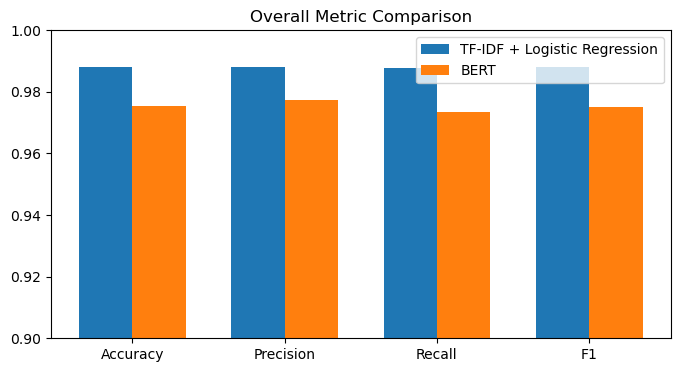

In [24]:
metrics = ["Accuracy", "Precision", "Recall", "F1"]
tfidf_vals = [acc_tfidf, prec_tfidf, rec_tfidf, f1_tfidf]
bert_vals  = [acc_bert,  prec_bert,  rec_bert,  f1_bert]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(8,4))
ax.bar(x - width/2, tfidf_vals, width, label="TF-IDF + Logistic Regression")
ax.bar(x + width/2, bert_vals, width, label="BERT")

ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0.9, 1.0)
ax.set_title("Overall Metric Comparison")
ax.legend()

plt.show()


### 3.1.3  Class-wise and error analysis

The class-wise results show that the TF-IDF model consistently outperforms BERT for both fake and real news across precision, recall, and F1 score. The difference is most noticeable for fake news recall, where TF-IDF identifies a higher proportion of fake articles and is therefore less likely to miss misinformation. The higher F1 scores across both classes also indicate that the TF-IDF model achieves a better balance between correctly detecting fake news and avoiding incorrect classification of real news. Overall, this suggests that TF-IDF is more reliable than BERT for both identifying misinformation and preserving legitimate content in this dataset.

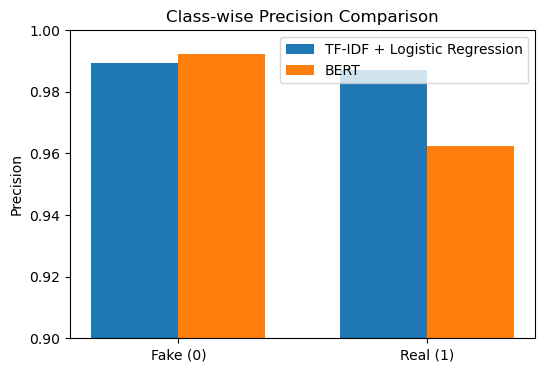

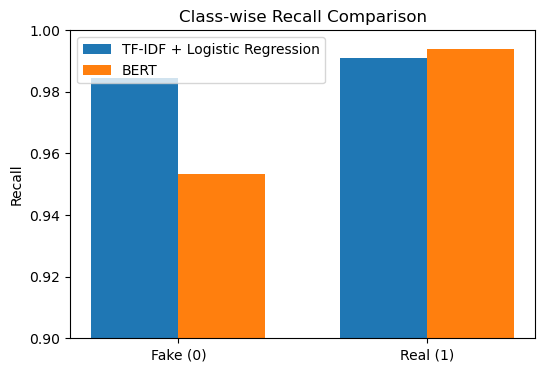

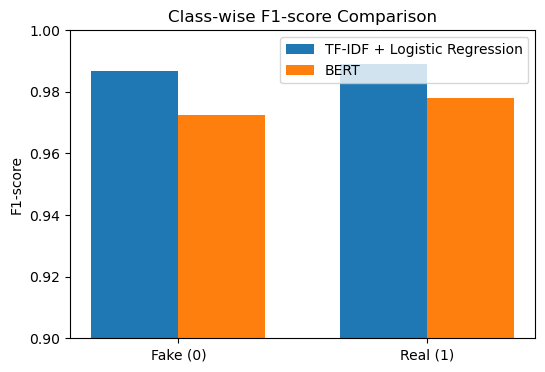

In [25]:
# --- Extract class-wise metrics ---
report_tfidf = classification_report(y_test, y_pred_lr, output_dict=True)
report_bert  = classification_report(all_labels, all_preds, output_dict=True)

classes = ["0", "1"]  # Fake = 0, Real = 1

precision_tfidf = [report_tfidf[c]["precision"] for c in classes]
precision_bert  = [report_bert[c]["precision"]  for c in classes]

recall_tfidf = [report_tfidf[c]["recall"] for c in classes]
recall_bert  = [report_bert[c]["recall"]  for c in classes]

f1_tfidf = [report_tfidf[c]["f1-score"] for c in classes]
f1_bert  = [report_bert[c]["f1-score"]  for c in classes]

# --- Plotting function ---
def plot_metric(tfidf_vals, bert_vals, metric_name):
    x = np.arange(2)
    width = 0.35

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.bar(x - width/2, tfidf_vals, width, label="TF-IDF + Logistic Regression")
    ax.bar(x + width/2, bert_vals,  width, label="BERT")

    ax.set_xticks(x)
    ax.set_xticklabels(["Fake (0)", "Real (1)"])
    ax.set_ylim(0.9, 1.0)
    ax.set_ylabel(metric_name)
    ax.set_title(f"Class-wise {metric_name} Comparison")
    ax.legend()

    plt.show()

# --- Plot all metrics ---
plot_metric(precision_tfidf, precision_bert, "Precision")
plot_metric(recall_tfidf, recall_bert, "Recall")
plot_metric(f1_tfidf, f1_bert, "F1-score")



### 3.1.4  Confusion Matrices

The confusion matrices show that the TF-IDF + Logistic Regression model makes fewer errors for both classes compared to BERT. Specifically, TF-IDF misclassifies 54 fake articles as real and 37 real articles as fake. In contrast, the BERT model misclassifies 172 fake articles as real and 113 real articles as fake. This indicates that BERT is more likely to miss fake news and more likely to incorrectly flag legitimate articles as fake. In a misinformation detection context, this behaviour is undesirable because it both allows more false content to pass through and increases the risk of penalising trustworthy news sources.t.

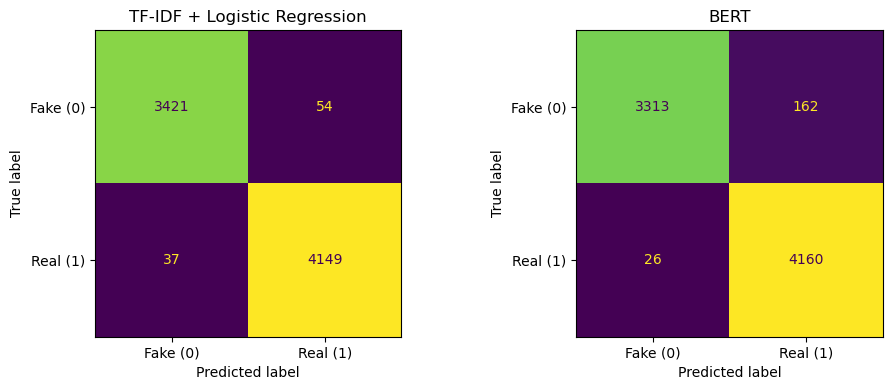

In [26]:
# Compute confusion matrices
cm_tfidf = confusion_matrix(y_test, y_pred_lr)
cm_bert  = confusion_matrix(all_labels, all_preds)

# Plot side by side
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

ConfusionMatrixDisplay(cm_tfidf, display_labels=["Fake (0)", "Real (1)"]).plot(ax=axes[0], colorbar=False)
axes[0].set_title("TF-IDF + Logistic Regression")

ConfusionMatrixDisplay(cm_bert, display_labels=["Fake (0)", "Real (1)"]).plot(ax=axes[1], colorbar=False)
axes[1].set_title("BERT")

plt.tight_layout()
plt.show()



### 3.1.5 Model Comparison and Discussion

The experimental results show that the TF-IDF + Logistic Regression model outperforms the BERT-based classifier across all evaluation metrics on this dataset. TF-IDF achieves higher accuracy, precision, recall, and F1-score, and also produces fewer misclassifications in both classes. This indicates that a simpler statistical model is better suited for this specific task and dataset, despite BERT’s greater representational capacity.

One key advantage of the TF-IDF approach is its strong alignment with the structure of the dataset. The fake and real news articles appear to differ clearly in vocabulary usage, stylistic patterns, and lexical choices. TF-IDF explicitly models word frequency and term importance, allowing the classifier to exploit these surface-level distinctions very effectively. As a result, it performs exceptionally well while remaining computationally efficient, easy to train, and highly interpretable. This makes TF-IDF particularly attractive in settings where transparency, speed, and low computational cost are important, such as real-time monitoring systems or environments with limited resources.

In contrast, BERT offers richer contextual and semantic representations, which are theoretically more powerful but also require substantially more data and training to reach their full potential. In this experiment, BERT was fine-tuned for only one epoch on a relatively limited dataset. This likely constrained its ability to adapt its deep representations to the specific linguistic cues that distinguish fake from real news in this corpus. As a result, BERT underperforms compared to the simpler model, despite being a more advanced architecture.

However, this does not imply that TF-IDF is universally superior. TF-IDF relies heavily on word frequency and does not capture deeper meaning, discourse structure, or contextual relationships between words. It may struggle in scenarios where fake and real articles use similar vocabulary but differ in subtle framing, sarcasm, narrative manipulation, or implied intent. In such cases, an embedding-based model like BERT would be expected to perform better because it can model context, semantics, and long-range dependencies.

Therefore, TF-IDF + Logistic Regression is preferable when the dataset exhibits strong lexical signals and when efficiency and interpretability are priorities. BERT is more suitable for complex linguistic environments, adversarial settings, or cross-domain generalisation tasks where surface-level patterns are insufficient and deeper semantic understanding is required.

The observed performance disparity is thus best explained by the match between model assumptions and data characteristics. In this dataset, lexical differences dominate, favouring frequency-based models. In more linguistically subtle or manipulated datasets, embedding-based approaches would likely provide a stronger advantage.

## 4.1 Project Summary and Reflections

This project investigated and compared a statistical and a deep learning approach for fake news classification, using TF-IDF with Logistic Regression as a baseline and BERT as a contextual embedding-based model. Through systematic evaluation using accuracy, precision, recall, F1-score, class-wise analysis, confusion matrices, and ROC curves, the project showed that the TF-IDF-based model consistently outperformed the BERT classifier on this dataset. While both models achieved strong performance, the TF-IDF approach demonstrated higher reliability, fewer misclassifications, and more stable behaviour across classes and error types.

A key insight from this work is that increased model complexity does not automatically lead to improved performance. Although BERT captures richer semantic and contextual information, its effectiveness depends on sufficient data, training time, and alignment with the task. In this case, the dataset exhibited strong lexical and stylistic differences between fake and real news articles, which were well captured by TF-IDF features. As a result, the simpler statistical model was better suited to the data and achieved superior performance. This highlights the importance of selecting models based on data characteristics rather than assuming that more sophisticated techniques will always perform better.

From a practical perspective, the TF-IDF + Logistic Regression model offers several advantages for real-world deployment. It is computationally efficient, fast to train and evaluate, easy to interpret, and straightforward to reproduce. These properties make it suitable for large-scale or real-time misinformation detection systems, especially in resource-constrained environments. In contrast, BERT requires substantially more computational resources and careful fine-tuning, but may be more effective in scenarios where misinformation is subtle, paraphrased, or semantically misleading rather than lexically distinctive.

The framework developed in this project is transferable to other text classification tasks such as spam detection, sentiment analysis, and topic classification, provided that similar preprocessing and evaluation pipelines are applied. However, performance is likely to vary across domains, languages, and data distributions.

Future work could explore more extensive fine-tuning of BERT, testing on larger or more diverse datasets, incorporating metadata features such as source credibility or publication timing, and evaluating robustness under domain shift or adversarial conditions. Extending the system to handle multimodal misinformation, such as images or videos, could further improve real-world applicability and generalisation.

# References (APA style)

- Allcott, H., & Gentzkow, M. (2017). Social media and fake news in the 2016 election. Journal of Economic Perspectives, 31(2), 211–236. https://doi.org/10.1257/jep.31.2.211

- Devlin, J., Chang, M.-W., Lee, K., & Toutanova, K. (2019). BERT: Pre-training of deep bidirectional transformers for language understanding. Proceedings of NAACL-HLT, 4171–4186.

- Mikolov, T., Chen, K., Corrado, G., & Dean, J. (2013). Efficient estimation of word representations in vector space. arXiv preprint arXiv:1301.3781.

- Shu, K., Sliva, A., Wang, S., Tang, J., & Liu, H. (2017). Fake news detection on social media: A data mining perspective. ACM SIGKDD Explorations Newsletter, 19(1), 22–36.

- Zhang, X., Zhao, J., & LeCun, Y. (2019). Character-level convolutional networks for text classification. Advances in Neural Information Processing Systems.

- Wang, W. Y. (2017). "Liar, liar pants on fire": A new benchmark dataset for fake news detection. Proceedings of the 55th Annual Meeting of the Association for Computational Linguistics (ACL), 422–426. https://doi.org/10.18653/v1/P17-2067

- Conroy, N. J., Rubin, V. L., & Chen, Y. (2015). Automatic deception detection: Methods for finding fake news. Proceedings of the Association for Information Science and Technology, 52(1), 1–4. https://doi.org/10.1002/pra2.2015.145052010082
- Bisaillon, C. (2018). Fake and real news dataset [Data set]. Kaggle. 
https://www.kaggle.com/datasets/clmentbisaillon/fake-and-real-news-dataset
